# Calibrating two-qubit gates
### From pulse amplitude to quantum evolution—and a reusable model bundle

In this tutorial you will:
1. Build an ideal two-qubit model.
2. Inspect the trial pulses and choose X and SWAP targets.
3. Calibrate pulse amplitudes and compare gate fidelities.
4. Watch computational-basis populations evolve.
5. Save the calibrated model, reload it, and check that its gates agree.

We work in a rotating frame with zero idle frequencies and zero idle coupling. This isolates the control problem; it is not a noisy hardware benchmark. Time is in consistent arbitrary units and $\hbar=1$.

## 1. Set up the notebook
Run cells in order from the repository root or `demo/`. CairoMakie renders the figures inline without a GUI window.

In [1]:
import Pkg
demo_dir = basename(pwd()) == "demo" ? pwd() : joinpath(pwd(), "demo")
isfile(joinpath(demo_dir, "Project.toml")) || error("Run this notebook from the repository root or demo directory")
Pkg.activate(demo_dir)
Pkg.instantiate(; allow_autoprecomp = false)

  Activating project at `~/Documents/CodingProjects/QuantumDevices.jl/demo`


┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Pkg/src/API.jl:1322


In [2]:
using LinearAlgebra
using QuantumDevices
using QuantumToolbox
using Printf
import OptimizationOptimJL
import SciMLBase
import CairoMakie
using CairoMakie: Figure, Axis, lines!, scatter!, axislegend, ylims!, xlims!

CairoMakie.activate!(type = "png")
CairoMakie.set_theme!(fontsize = 15, linewidth = 2.5,
    Axis = (xgridvisible = false, ygridcolor = (:gray, 0.15),
            topspinevisible = false, rightspinevisible = false))
gate_names = (:X1, :X2, :SWAP)
gate_colors = (X1 = "#2563EB", X2 = "#0D9488", SWAP = "#9333EA")
figures = Dict{String,Figure}();

[ Info: Precompiling QuantumDevices [2922de0c-2856-4bd8-898b-94dde52865ea](cache misses: include_dependency fsize change (1), wrong dep version loaded (5), mismatched flags (4))


[ Info: Precompiling QuantumDevices [2922de0c-2856-4bd8-898b-94dde52865ea] (cache misses: include_dependency fsize change (2), wrong dep version loaded (10), mismatched flags (8))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: cau

[ Info: Precompiling OptimizationOptimJL [36348300-93cb-4f02-beb5-3c3902f8871e](cache misses: wrong dep version loaded (4), incompatible header (4), mismatched flags (1))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Precompiling OptimizationOptimJL [36348300-93cb-4f02-beb5-3c3902f8871e] (cache misses: wrong dep version loaded (8), incompatible header (8), mismatched flags (2))


...


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling SciMLBaseMakieExt [565f26a4-c902-5eae-92ad-e10714a9d9de] (cache misses: wrong dep version loaded (16), mismatched flags (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


┌ Warning: Module SciMLBase with build ID fafbfcfd-a604-b61b-5f7e-8ae023f3b815 is missing from the cache.
│ This may mean SciMLBase [0bca4576-84f4-4d90-8ffe-ffa030f20462] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2643
┌ Info: Skipping precompilation due to precompilable error. Importing SciMLBaseMakieExt [565f26a4-c902-5eae-92ad-e10714a9d9de].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
[ Info: Precompiling Cairo [159f3aea-2a34-519c-b102-8c37f9878175](cache misses: wrong dep version loaded (7), mismatched flags (2))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Precompiling Cairo [159f3aea-2a34-519c-b102-8c37f9878175] (cache misses: wrong dep version loaded (14), mismatched flags (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 2. Build the model
The tensor ordering is **q1 ⊗ q2**: $|10\rangle$ means q1 is excited and q2 is in its ground state. The retained Hilbert space has dimension four.

We retain an interaction parameter `J_idle` in the model, set to zero here. The exchange operator will also be reused for the driven SWAP.

In [3]:
q1 = make_qubit("q1", 0.0)
q2 = make_qubit("q2", 0.0)
exchange = op(:q1_x) * op(:q2_x) + op(:q1_y) * op(:q2_y) + op(:q1_z) * op(:q2_z)
model = make_model([q1, q2], param(:J_idle) * exchange, (J_idle = 0.0,))
model

DeviceModel(2 components, dimension=4)
  Components: ["q1", "q2"]
  Parameters: (q1_ν = 0.0, J_idle = 0.0, q2_ν = 0.0)
  Operators: 10
  Compiled terms: 5
  Gates: Any[]

## 3. Choose controls and targets
Use constant pulses for an analytically checkable first example:

| Gate | Driven Hamiltonian | Desired action | Ideal amplitude at T = 1 |
|:--|:--|:--|:--|
| X1 | $A X_1$ | $|00\rangle \to |10\rangle$ | $\pi/2$ |
| X2 | $A X_2$ | $|00\rangle \to |01\rangle$ | $\pi/2$ |
| SWAP | $J(X_1X_2+Y_1Y_2+Z_1Z_2)$ | $|10\rangle \to |01\rangle$ | $\pi/4$ |

These amplitudes implement the targets up to a global phase. The **ZZ term matters**: an XX+YY exchange alone produces an iSWAP-type operation, not the full SWAP target used here. Calibration starts deliberately below the ideal amplitudes.

In [4]:
duration = 1.0
initial_gates = (
    X1 = DeviceGate((drive = constant_pulse(0.4),), param(:drive) * op(:q1_x), duration),
    X2 = DeviceGate((drive = constant_pulse(0.4),), param(:drive) * op(:q2_x), duration),
    SWAP = DeviceGate((drive = constant_pulse(0.25),), param(:drive) * exchange, duration),
)
targets = (
    X1 = tensor(sigmax(), qeye(2)),
    X2 = tensor(qeye(2), sigmax()),
    SWAP = (tensor(qeye(2), qeye(2)) + tensor(sigmax(), sigmax()) +
            tensor(sigmay(), sigmay()) + tensor(sigmaz(), sigmaz())) / 2,
)
expected_amplitudes = (X1 = pi / (2duration), X2 = pi / (2duration), SWAP = pi / (4duration))
amplitude(gate) = getpath(gate, "drive/amplitude")

amplitude (generic function with 1 method)

### Inspect the initial pulses
The pulse amplitude is constant during the gate and zero outside it. Dashed lines mark the analytic amplitudes we expect calibration to recover. The displayed drive values are Hamiltonian coefficients, not qubit transition frequencies.

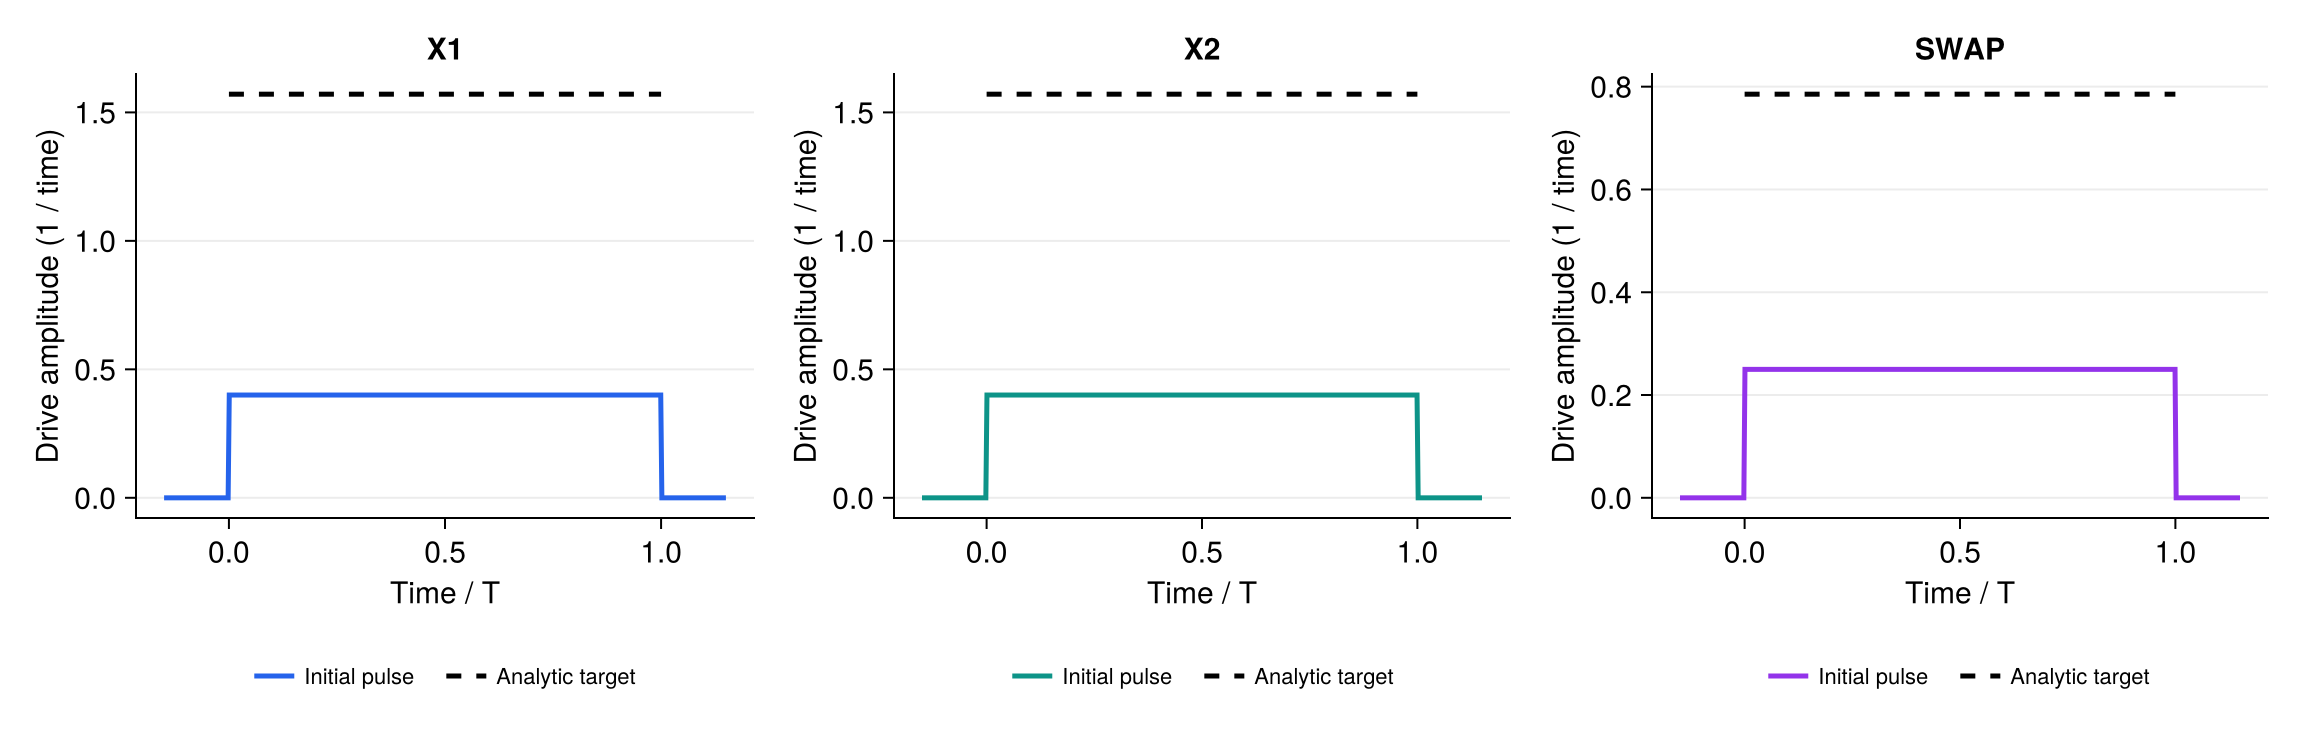

In [5]:
pulse_times = collect(range(-0.15duration, 1.15duration; length = 501))
trial_pulses = Figure(size = (1150, 370))
for (column, name) in enumerate(gate_names)
    ax = Axis(trial_pulses[1, column], title = string(name),
        xlabel = "Time / T", ylabel = "Drive amplitude (1 / time)")
    pulse = initial_gates[name].parameters.drive
    lines!(ax, pulse_times ./ duration, [pulse(t, duration) for t in pulse_times];
        color = gate_colors[name], label = "Initial pulse")
    lines!(ax, [0, 1], fill(expected_amplitudes[name], 2);
        color = :black, linestyle = :dash, label = "Analytic target")
    CairoMakie.Legend(trial_pulses[2, column], ax; orientation = :horizontal, labelsize = 11, framevisible = false)
end
figures["01_initial_pulses"] = trial_pulses
trial_pulses

## 4. Calibrate the amplitudes
We minimize the phase-insensitive **process infidelity**

$$1-F_{\mathrm{pro}} = 1-\frac{|\operatorname{Tr}(U_{\mathrm{target}}^\dagger U)|^2}{d^2},\qquad d=4.$$

This compares the entire unitary, not just a single state transfer. For unitary gates the average gate fidelity is $(d F_{\mathrm{pro}}+1)/(d+1)$.

Inspect `parameters(gate)` to see names, paths, and current values. Pass a list such as `["drive/amplitude"]` to select what to optimize; direct scalar parameters use names such as `"q1_nu"`. Names match the actual parameter keys, including any Unicode characters. `calibration_problem` creates a standard SciML problem; we explicitly choose Nelder–Mead. Tight evolution tolerances keep numerical integration error below the displayed calibration errors.

In [6]:
accurate_unitary(model, gate) = gate_unitary(model, gate; abstol = 1e-10, reltol = 1e-10)
objective(model, gate, target) = unitary_infidelity(target, accurate_unitary(model, gate))

display(parameters(initial_gates.X1))

# Inspect one setup before solving all three gates.
x1_setup = calibration_problem(model, initial_gates.X1, ["drive/amplitude"], targets.X1; objective)
(; selected_amplitude = amplitude(initial_gates.X1),
   initial_infidelity = objective(model, initial_gates.X1, targets.X1))

Dict{String, Tuple} with 4 entries:
  "drive/offset"    => ("drive/offset", 0)
  "drive/stop"      => ("drive/stop", nothing)
  "drive/start"     => ("drive/start", 0)
  "drive/amplitude" => ("drive/amplitude", 0.4)

(selected_amplitude = 0.4, initial_infidelity = 0.8483533546735813)

In [7]:
solutions = Dict{Symbol,Any}()
loss_history = Dict(name => Float64[] for name in gate_names)
results = map(gate_names) do name
    initial_gate, target = initial_gates[name], targets[name]
    # Record objective evaluations, not optimizer iterations.
    recorded_objective(m, g, target) = begin
        loss = objective(m, g, target)
        push!(loss_history[name], loss)
        loss
    end
    setup = calibration_problem(model, initial_gate, ["drive/amplitude"], target;
        objective = recorded_objective)
    solution, calibrated = calibrate(setup, OptimizationOptimJL.NelderMead(); maxiters = 200)
    @assert SciMLBase.successful_retcode(solution.retcode)
    solutions[name] = solution
    model.gates[name] = calibrated

    U, V = Matrix(accurate_unitary(model, calibrated).data), Matrix(target.data)
    phase = tr(V' * U) / abs(tr(V' * U))
    matrix_error = norm(U - phase * V) / norm(V)
    unitarity_error = norm(U' * U - I)
    final_infidelity = unitary_infidelity(target, U)
    @assert final_infidelity < 1e-7 && matrix_error < 1e-3 && unitarity_error < 1e-7
    @assert isapprox(amplitude(calibrated), expected_amplitudes[name]; atol = 1e-3)
    @assert amplitude(initial_gate) == (name === :SWAP ? 0.25 : 0.4)
    (; gate = name, initial_infidelity = objective(model, initial_gate, target),
       amplitude = amplitude(calibrated), final_infidelity, matrix_error, unitarity_error)
end;

### Read the calibration results
The left panel shows the best infidelity found so far against **objective evaluation count**. The right panel compares starting and calibrated errors on a logarithmic scale. Values are floored at `1e-14` for plotting only; the table reports the computed values.

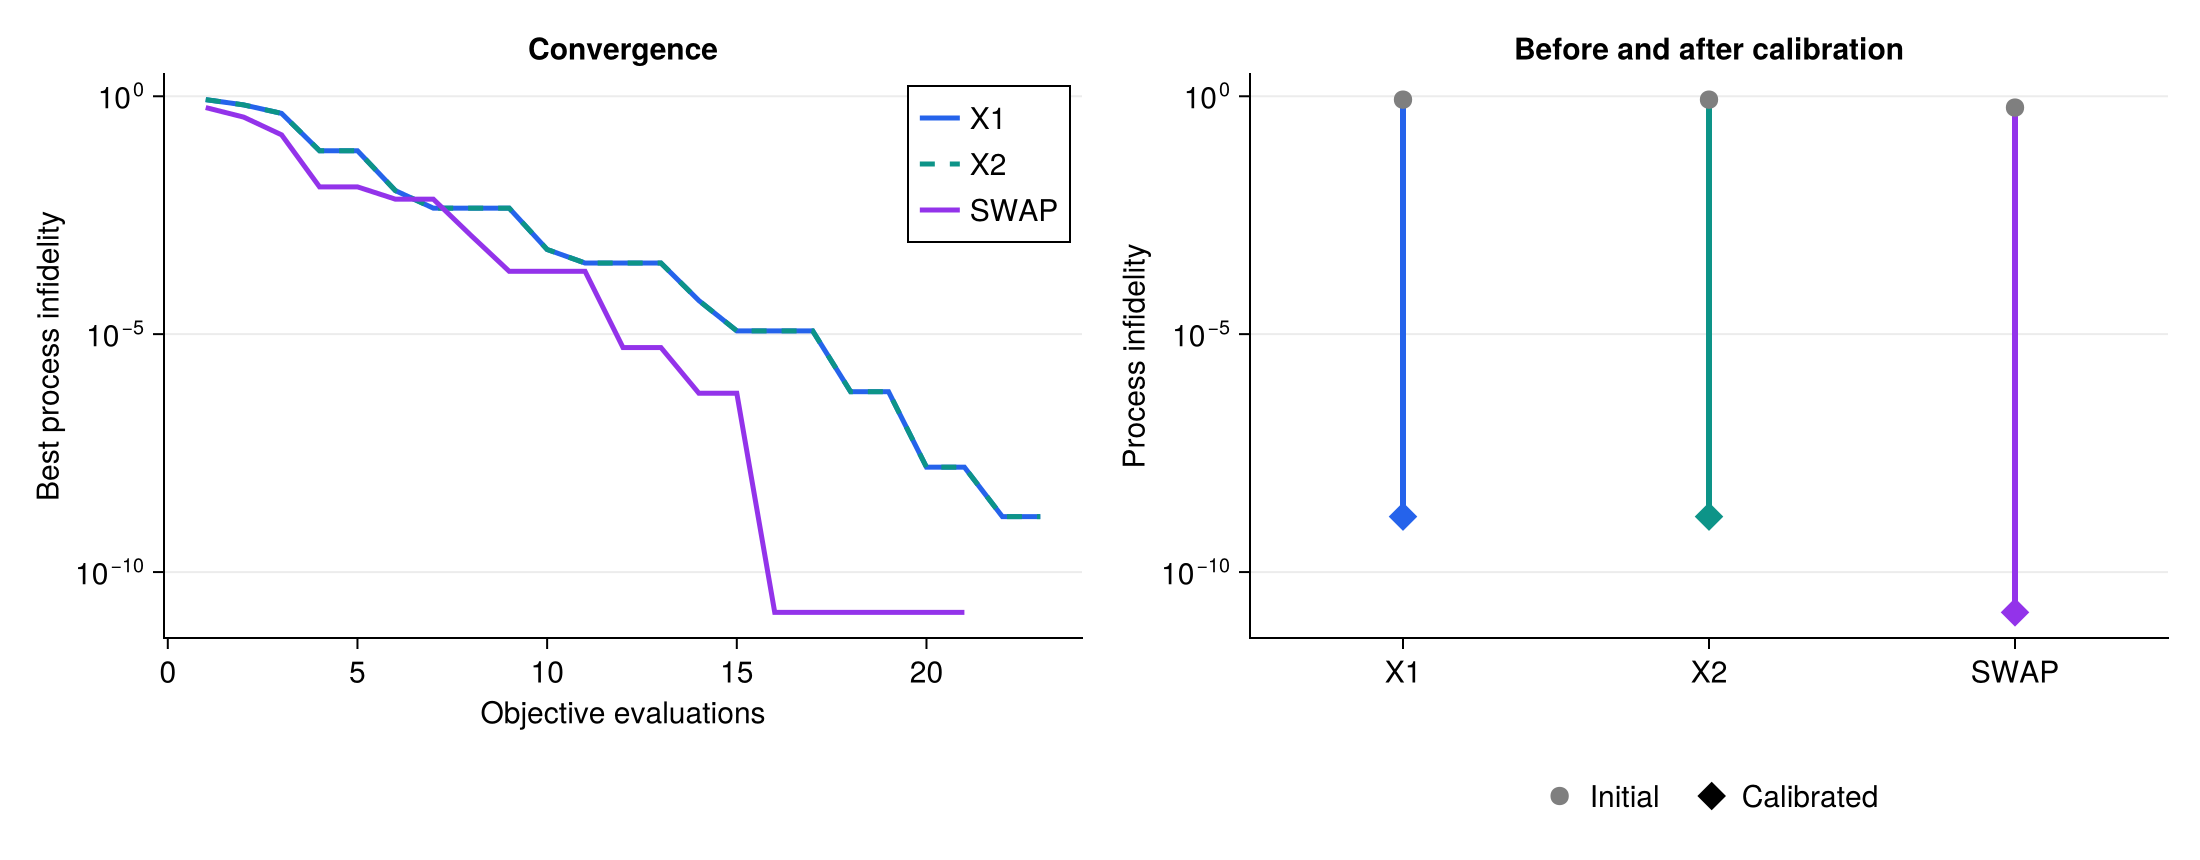

In [8]:
calibration_figure = Figure(size = (1100, 430))
ax_loss = Axis(calibration_figure[1, 1], xlabel = "Objective evaluations", ylabel = "Best process infidelity",
    title = "Convergence", yscale = log10)
for name in gate_names
    losses = accumulate(min, loss_history[name])
    lines!(ax_loss, eachindex(losses), max.(losses, 1e-14); color = gate_colors[name], linestyle = name === :X2 ? :dash : :solid, label = string(name))
end
axislegend(ax_loss; position = :rt)
ax_compare = Axis(calibration_figure[1, 2], title = "Before and after calibration",
    ylabel = "Process infidelity", xticks = (1:3, collect(string.(gate_names))), yscale = log10)
for (i, result) in enumerate(results)
    lines!(ax_compare, [i, i], max.([result.initial_infidelity, result.final_infidelity], 1e-14);
        color = gate_colors[result.gate], linewidth = 3)
end
scatter!(ax_compare, 1:3, [r.initial_infidelity for r in results];
    color = :gray50, marker = :circle, markersize = 13, label = "Initial")
scatter!(ax_compare, 1:3, max.([r.final_infidelity for r in results], 1e-14);
    color = [gate_colors[n] for n in gate_names], marker = :diamond, markersize = 16, label = "Calibrated")
xlims!(ax_compare, 0.5, 3.5)
CairoMakie.Legend(calibration_figure[2, 2], ax_compare; orientation = :horizontal, framevisible = false)
figures["02_calibration"] = calibration_figure
calibration_figure

In [9]:
rows = join(map(results) do r
    @sprintf("<tr><td>%s</td><td>%.6f</td><td>%.6f</td><td>%.9f</td><td>%.2e</td></tr>",
        string(r.gate), r.amplitude, expected_amplitudes[r.gate], 1-r.final_infidelity, r.final_infidelity)
end)
display(MIME"text/html"(), """
<style>.gate-results {border-collapse: collapse; font-variant-numeric: tabular-nums;}
.gate-results th, .gate-results td {padding: 10px 18px; text-align: right; border-bottom: 1px solid #ddd;}
.gate-results th {background: #eef2f7; color: #172033;}
.gate-results td:first-child, .gate-results th:first-child {text-align: left;}</style>
<table class="gate-results"><thead><tr><th>Gate</th><th>Fitted amplitude</th><th>Analytic amplitude</th>
<th>Process fidelity</th><th>Process infidelity</th></tr></thead><tbody>$rows</tbody></table>
""")

Gate,Fitted amplitude,Analytic amplitude,Process fidelity,Process infidelity
X1,1.570758,1.570796,0.999999999,1.46e-09
X2,1.570758,1.570796,0.999999999,1.46e-09
SWAP,0.785400,0.785398,1.000000000,1.42e-11


## 5. Inspect the calibrated pulses
Solid curves are calibrated; dotted curves are the original guesses. The target markers make the agreement with the analytic amplitudes visible.

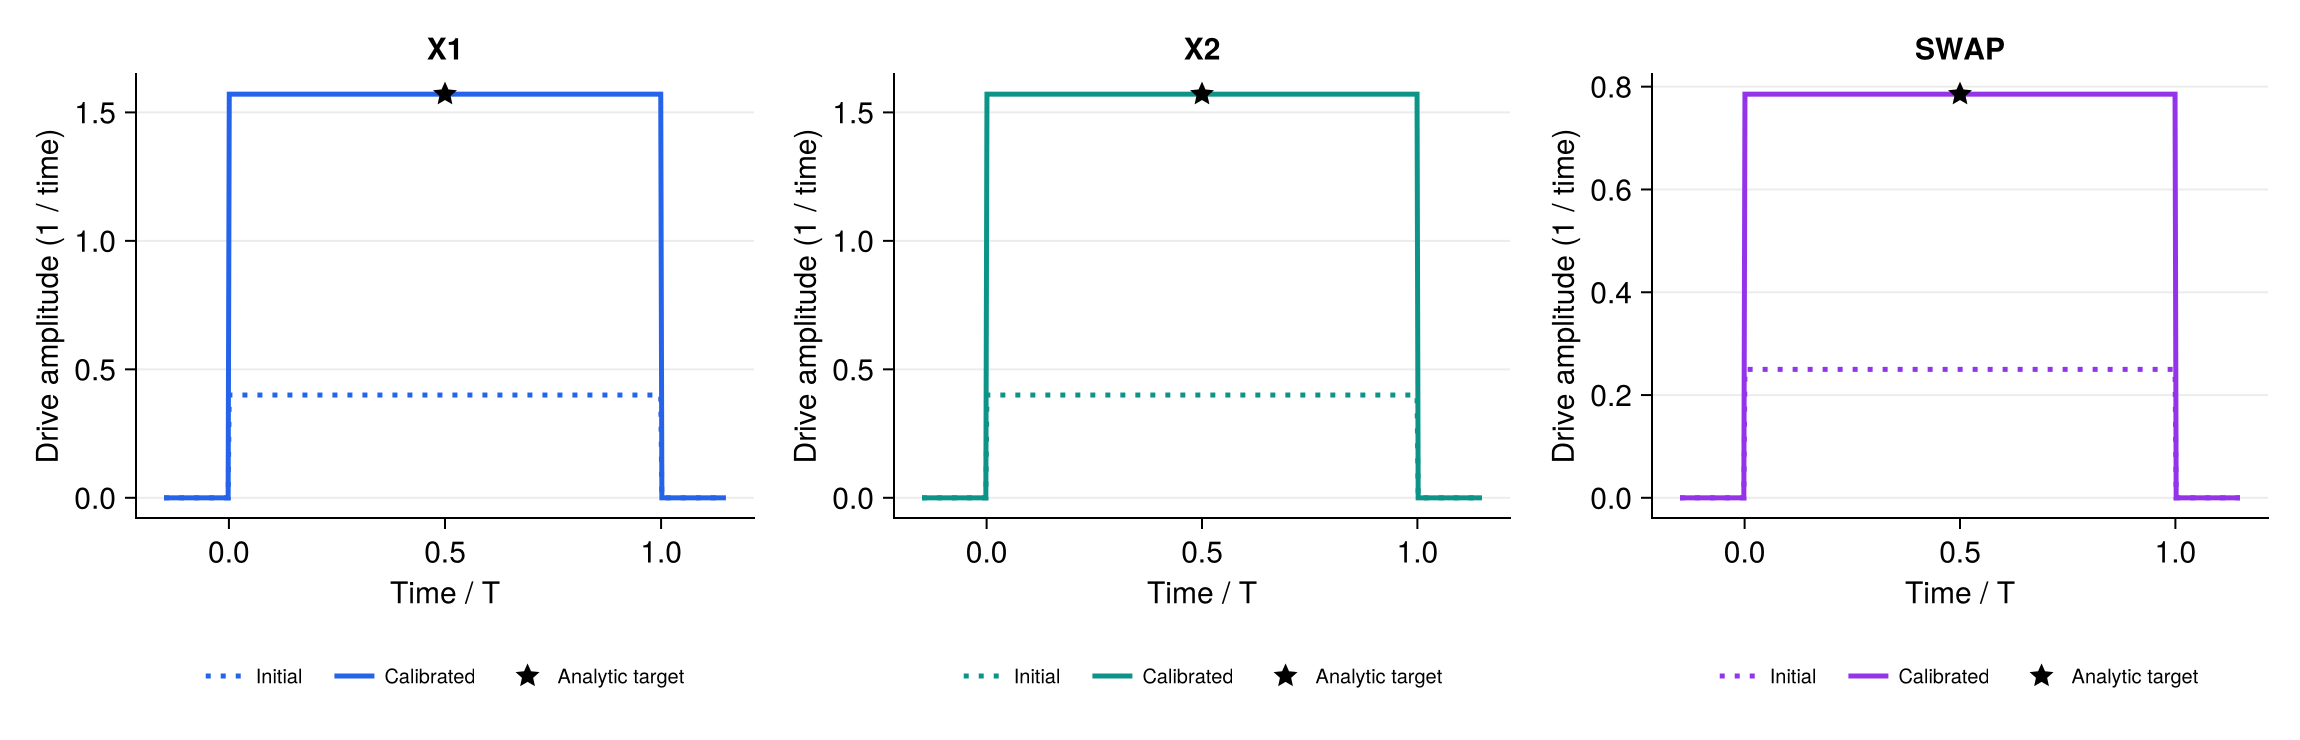

In [10]:
pulse_figure = Figure(size = (1150, 370))
for (column, name) in enumerate(gate_names)
    ax = Axis(pulse_figure[1, column], title = string(name), xlabel = "Time / T", ylabel = "Drive amplitude (1 / time)")
    for (gate, style, label) in ((initial_gates[name], :dot, "Initial"), (model.gates[name], :solid, "Calibrated"))
        lines!(ax, pulse_times ./ duration, [gate.parameters.drive(t, duration) for t in pulse_times];
            color = gate_colors[name], linestyle = style, label)
    end
    scatter!(ax, [0.5], [expected_amplitudes[name]]; color = :black, marker = :star5,
        markersize = 14, label = "Analytic target")
    CairoMakie.Legend(pulse_figure[2, column], ax; orientation = :horizontal, labelsize = 10, framevisible = false)
end
figures["03_calibrated_pulses"] = pulse_figure
pulse_figure

## 6. Watch the states evolve
We now solve the Schrödinger equation on a time grid, using the same gate Hamiltonians used during calibration.

- X1: start in $|00\rangle$ and aim for $|10\rangle$.
- X2: start in $|00\rangle$ and aim for $|01\rangle$.
- SWAP: start in $|10\rangle$ and aim for $|01\rangle$.

**Solid lines** show calibrated evolution; **dotted lines** show the initial pulses. These populations are illustrative state transfers: population measurements alone cannot establish the relative phases needed for a correct quantum gate. The full-unitary checks above address that.

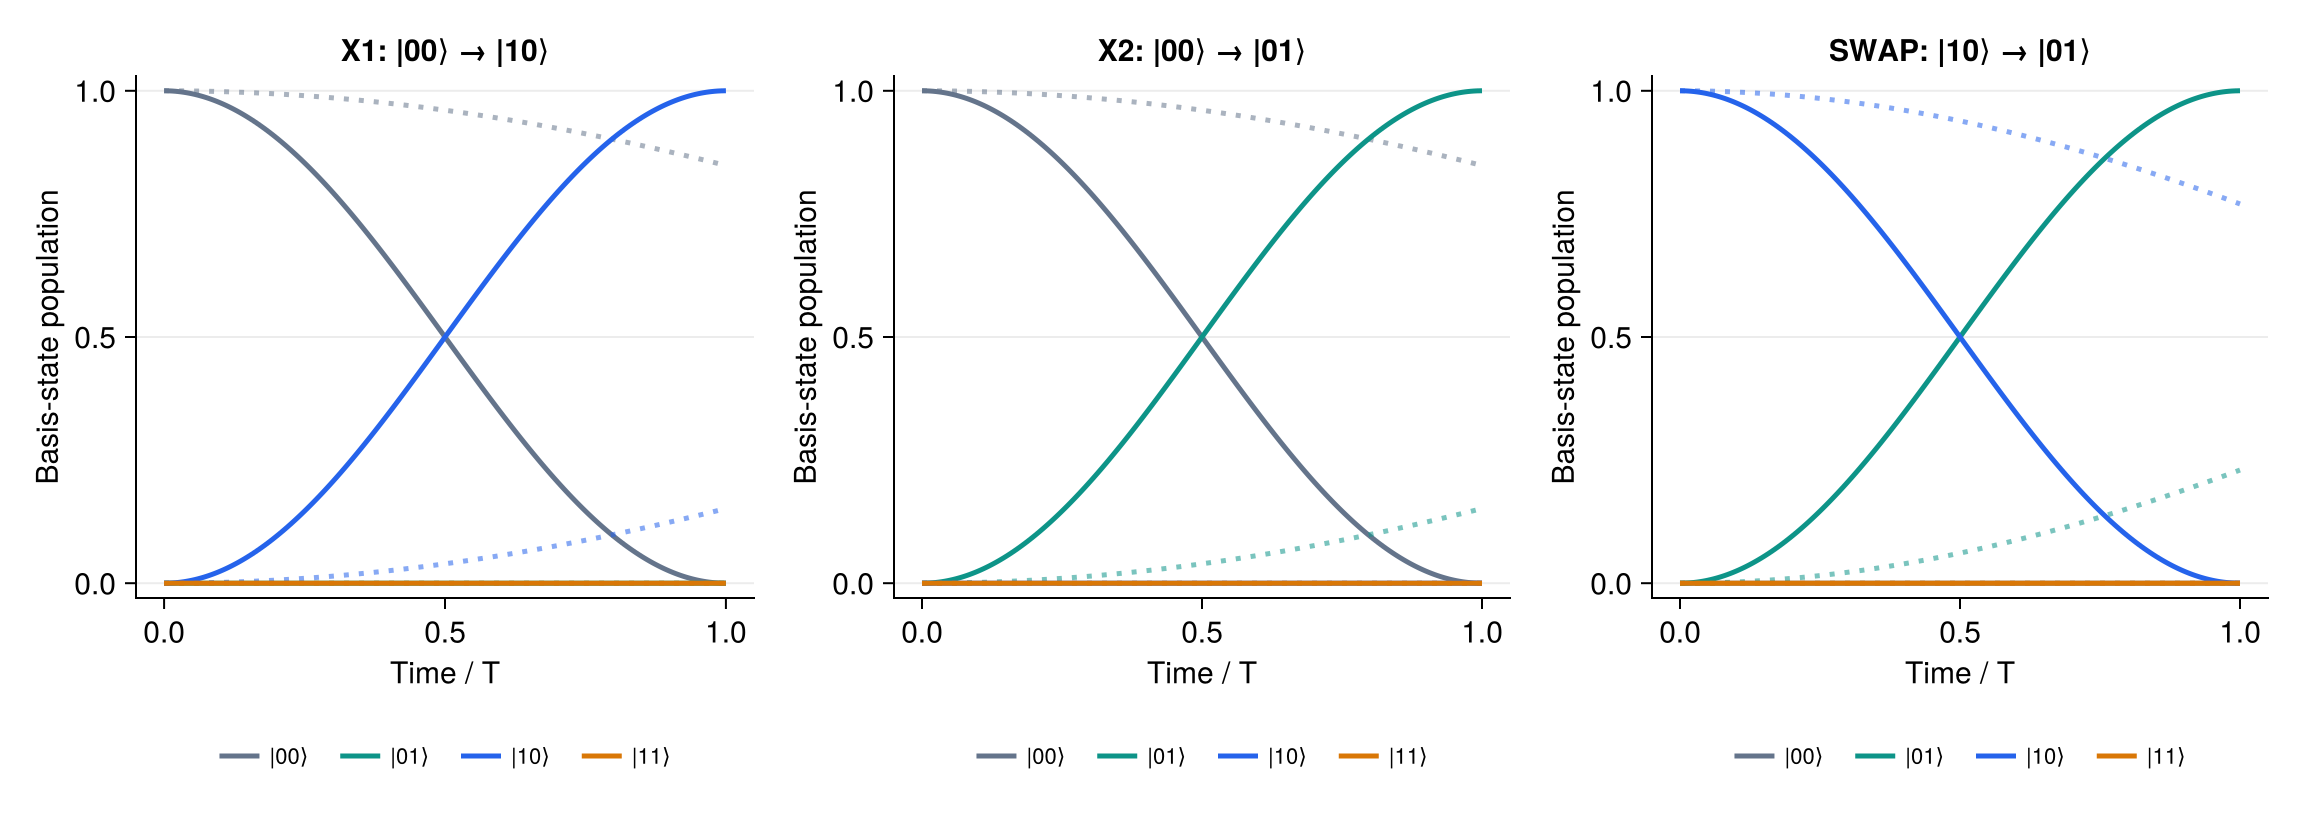

In [11]:
basis_states = [tensor(basis(2, i), basis(2, j)) for (i, j) in ((0, 0), (0, 1), (1, 0), (1, 1))]
state_labels = ["|00⟩", "|01⟩", "|10⟩", "|11⟩"]
state_colors = ["#64748B", "#0D9488", "#2563EB", "#D97706"]
inputs = (X1 = basis_states[1], X2 = basis_states[1], SWAP = basis_states[3])
output_indices = (X1 = 3, X2 = 2, SWAP = 2)
times = collect(range(0, duration; length = 201))
trajectories = Dict{Tuple{Symbol,Symbol},Matrix{Float64}}()
for name in gate_names, (stage, gate) in ((:initial, initial_gates[name]), (:calibrated, model.gates[name]))
    solution = sesolve(numerical(model, gate), inputs[name], times;
        abstol = 1e-10, reltol = 1e-10, progress_bar = false)
    @assert SciMLBase.successful_retcode(solution.retcode)
    populations = [abs2(dot(state.data, psi.data)) for state in basis_states, psi in solution.states]
    @assert maximum(abs.(vec(sum(populations; dims = 1)) .- 1)) < 1e-7
    trajectories[(name, stage)] = populations
    stage === :calibrated && @assert populations[output_indices[name], end] > 1 - 1e-7
end
population_figure = Figure(size = (1150, 410))
for (column, name) in enumerate(gate_names)
    input_label = name === :SWAP ? "|10⟩" : "|00⟩"
    ax = Axis(population_figure[1, column], title = "$(name): $input_label → $(state_labels[output_indices[name]])",
        xlabel = "Time / T", ylabel = "Basis-state population")
    for state_index in 1:4
        lines!(ax, times ./ duration, trajectories[(name, :initial)][state_index, :];
            color = (state_colors[state_index], 0.55), linestyle = :dot)
        lines!(ax, times ./ duration, trajectories[(name, :calibrated)][state_index, :];
            color = state_colors[state_index], label = state_labels[state_index])
    end
    ylims!(ax, -0.03, 1.03)
    CairoMakie.Legend(population_figure[2, column], ax; orientation = :horizontal, labelsize = 11, framevisible = false)
end
figures["04_state_populations"] = population_figure
population_figure

## 7. Save and reload the calibrated model
The model now owns `:X1`, `:X2`, and `:SWAP`. Save a new bundle on each run. Component and idle-interaction parameters live in `parameters.json`; gate parameters live in the gate records. Plot exports are kept alongside the bundle.

The reloaded object is called `loaded_model`, leaving the original `model` available for comparison.

In [12]:
output_dir = joinpath(demo_dir, "output")
mkpath(output_dir)
run_dir = mktempdir(output_dir; prefix = "calibration-", cleanup = false)
bundle_path = QuantumDevices.save(joinpath(run_dir, "two_qubit_model"), model)
figure_dir = joinpath(run_dir, "figures")
mkpath(figure_dir)
for (name, figure) in figures
    CairoMakie.save(joinpath(figure_dir, name * ".png"), figure; px_per_unit = 2)
    CairoMakie.save(joinpath(figure_dir, name * ".pdf"), figure)
end
loaded_model = QuantumDevices.load(bundle_path)
@assert loaded_model !== model
@assert loaded_model.parameters == model.parameters
@assert loaded_model.H ≈ model.H
@assert Set(keys(loaded_model.gates)) == Set(gate_names)
(; bundle_path, figure_dir)

(bundle_path = "/Users/gavinrockwood/Documents/CodingProjects/QuantumDevices.jl/demo/output/calibration-dZoJmj/two_qubit_model", figure_dir = "/Users/gavinrockwood/Documents/CodingProjects/QuantumDevices.jl/demo/output/calibration-dZoJmj/figures")

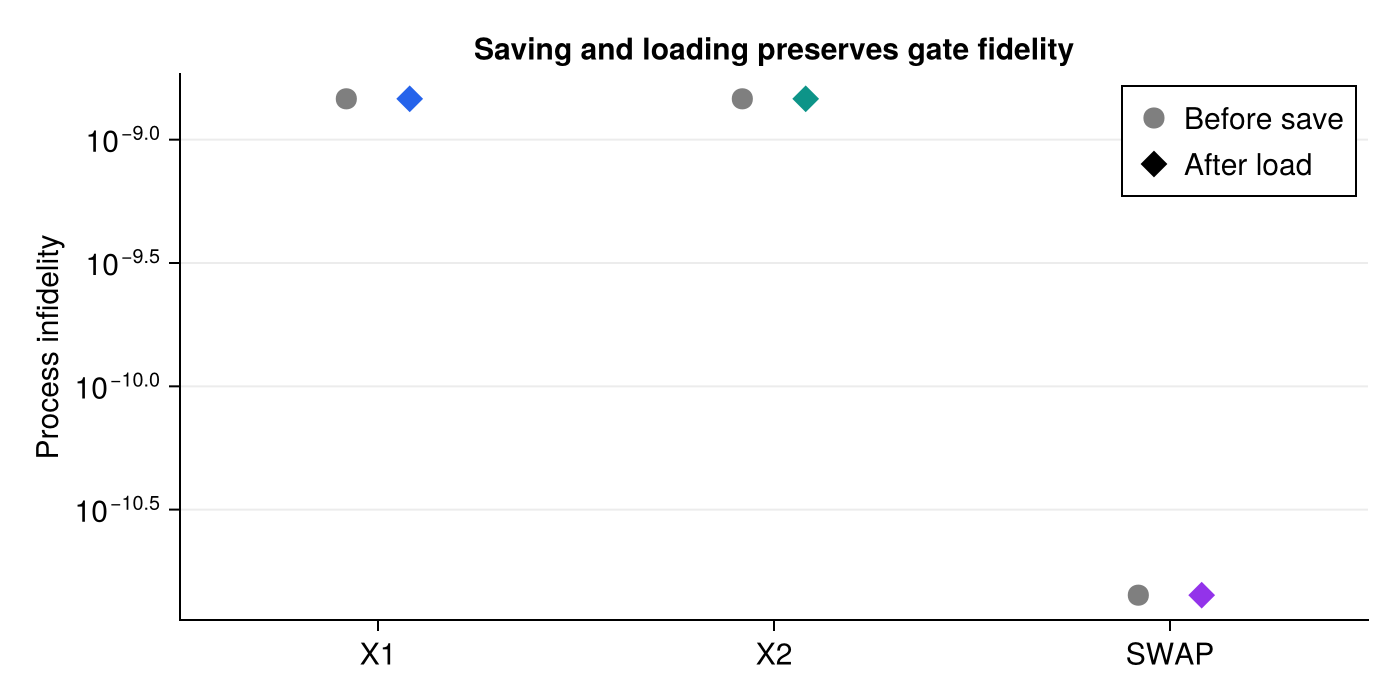

In [13]:
loaded_infidelities = map(gate_names) do name
    restored_gate = loaded_model.gates[name]
    @assert amplitude(restored_gate) == amplitude(model.gates[name])
    restored_U = accurate_unitary(loaded_model, restored_gate)
    @assert restored_U ≈ accurate_unitary(model, model.gates[name])
    error = unitary_infidelity(targets[name], restored_U)
    @assert error < 1e-7
    error
end
reload_figure = Figure(size = (700, 350))
ax = Axis(reload_figure[1, 1], title = "Saving and loading preserves gate fidelity",
    ylabel = "Process infidelity", xticks = (1:3, collect(string.(gate_names))), yscale = log10)
scatter!(ax, (1:3) .- 0.08, max.([r.final_infidelity for r in results], 1e-14);
    color = :gray50, markersize = 15, label = "Before save")
scatter!(ax, (1:3) .+ 0.08, max.(collect(loaded_infidelities), 1e-14);
    color = [gate_colors[n] for n in gate_names], marker = :diamond, markersize = 15, label = "After load")
xlims!(ax, 0.5, 3.5)
axislegend(ax; position = :rt)
CairoMakie.save(joinpath(figure_dir, "05_reload_fidelity.png"), reload_figure; px_per_unit = 2)
CairoMakie.save(joinpath(figure_dir, "05_reload_fidelity.pdf"), reload_figure)
reload_figure

## Try next
- Change the initial amplitudes and compare the objective-evaluation traces.
- Change `duration` and scale the analytic amplitudes as `π/(2T)` for X and `π/(4T)` for SWAP.
- Replace the constant pulse with a shaped built-in pulse. The required amplitude changes with pulse area.

With nonzero idle frequencies or coupling, the simple analytic targets above no longer follow from pulse area alone. Revisit the control Hamiltonian and target frame before interpreting calibration results.